# Thesis Pipeline Overview

This notebook focuses on displaying the thesis figure panels from the already prepared summary tables in `results/thesis_pipeline_overview`.

Workflow:
1. Load the prepared tables.
2. Load the dataset-analysis summary tables, including the precomputed label multiplicity counts.
3. Assemble and display the final combined figure without Panel A.


In [26]:
from pathlib import Path

try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
OUTPUT_DIR = ROOT / 'results' / 'thesis_pipeline_overview'

STAGE_COUNTS_PATH = OUTPUT_DIR / 'pipeline_stage_counts.csv'
CONSENSUS_BRIDGE_PATH = OUTPUT_DIR / 'pipeline_consensus_rescue_bridge.csv'
DROPOUT_PATH = OUTPUT_DIR / 'pipeline_dropout_reasons.csv'
VARIANTS_PATH = OUTPUT_DIR / 'variant_label_counts_long.csv'
VALIDATION_PATH = OUTPUT_DIR / 'pipeline_accounting_validation.csv'
STAGE_CHECKS_PATH = OUTPUT_DIR / 'pipeline_stage_consistency_checks.csv'

PEPTIDE_MAPPING_PATH = ROOT / 'data' / 'peptide_mapping.csv'

DATASET_ANALYSIS_DIR = ROOT / 'results' / 'thesis_dataset_analysis'
WT_DISTANCE_COUNTS_PATH = DATASET_ANALYSIS_DIR / 'dataset_wt_distance_counts.csv'
PAIRWISE_DISTANCE_PATH = DATASET_ANALYSIS_DIR / 'dataset_pairwise_hamming_distances.csv'
CROSSREACT_DEPTH_PATH = DATASET_ANALYSIS_DIR / 'dataset_crossreactive_binder_depth.csv'
SINGLE_BINDER_CONTEXT_PATH = DATASET_ANALYSIS_DIR / 'dataset_single_binder_context_by_peptide.csv'
LABEL_MULTIPLICITY_PATH = DATASET_ANALYSIS_DIR / 'dataset_label_multiplicity_counts.csv'
DATASET_ANALYSIS_VALIDATION_PATH = DATASET_ANALYSIS_DIR / 'dataset_analysis_validation.csv' 


In [27]:
stage_counts = pd.read_csv(STAGE_COUNTS_PATH)
consensus_bridge = pd.read_csv(CONSENSUS_BRIDGE_PATH)
dropout = pd.read_csv(DROPOUT_PATH)
variants = pd.read_csv(VARIANTS_PATH)
validation = pd.read_csv(VALIDATION_PATH)
stage_checks = pd.read_csv(STAGE_CHECKS_PATH)
peptide_mapping = pd.read_csv(PEPTIDE_MAPPING_PATH)
PEPTIDE_DISPLAY_NAMES = dict(zip(peptide_mapping['AA Sequence'], peptide_mapping['Name']))
PEPTIDE_DISPLAY_NAMES.update({
    'EVDPIGHLY': 'MAGE-A3',
    'ESDPIVAQY': 'Titin',
    'ECDPIYAAY': 'AN_HHV8P',
    'EGDPLILQY': 'ANR16',
    'EMDPVTQLY': 'CD166',
    'ETDPVNHMV': 'FAT2',
    'EVDPIGHVY': 'MAGE-A6',
    'EVDPIRHYY': 'MAGBI',
    'ETDPVENTY': 'MRCKA',
    'ETDPLTFNF': 'PLD5',
    'KH157': 'AN_HHV8P',
    'KH158': 'ANR16',
    'KH159': 'CD166',
    'KH160': 'FAT2',
    'KH163': 'MAGE-A6',
    'KH164': 'MAGBI',
    'KH165': 'MRCKA',
    'KH167': 'PLD5',
})

validation_summary = (
    validation.assign(abs_delta=validation['delta'].abs())
    .groupby(['dataset', 'step'], as_index=False)
    .agg(
        samples=('sample_id', 'count'),
        exact_samples=('passes_exact_accounting', 'sum'),
        max_abs_delta=('abs_delta', 'max'),
        total_delta=('delta', 'sum'),
    )
)

display(stage_counts)
display(consensus_bridge)
display(stage_checks)
display(validation_summary)


,dataset,stage,stage_order,count,count_unit,retention_from_raw
0,DMF5,Raw reads,0,387570891,reads,1.000000
1,DMF5,After trimming,1,186293144,reads,0.480669
2,DMF5,UMI input,2,186293144,reads,0.480669
3,DMF5,Consensus UMI,3,14605529,umi_groups,0.037685
4,DMF5,Consensus UMI + singleton rescue,4,15966064,consensus_umi_plus_rescued_singletons,0.041195
5,DMF5,Extraction input,5,15966064,consensus_umi_plus_rescued_singletons,0.041195
6,DMF5,Extraction PASS,6,10031675,reads,0.025883
7,TCRA3,Raw reads,0,1397372220,reads,1.000000
8,TCRA3,After trimming,1,661586299,reads,0.473450
9,TCRA3,UMI input,2,661586299,reads,0.473450


,dataset,consensus_umis,rescued_singletons,direct_singletons_without_rescue,singleton_addition_to_extraction,consensus_plus_rescue,extraction_input,delta
0,DMF5,14605529,1360535,0,1360535,15966064,15966064,0
1,TCRA3,83588684,36925819,0,36925819,120514503,120514503,0


,dataset,check,left_value,right_value,delta,passes
0,DMF5,trimming_out_equals_umi_input,186293144,186293144,0,True
1,DMF5,umi_accounting,186293144,186293144,0,True
2,DMF5,singletons_match_rescue_input_on_rescue_projects,11347626,11347626,0,True
3,DMF5,consensus_plus_singleton_addition_equals_extra...,15966064,15966064,0,True
4,DMF5,rescued_le_extracted,1360535,4118069,-2757534,True
5,DMF5,extracted_le_rescue_input,4118069,11347626,-7229557,True
6,TCRA3,trimming_out_equals_umi_input,661586299,661586299,0,True
7,TCRA3,umi_accounting,661586299,661586299,0,True
8,TCRA3,singletons_match_rescue_input_on_rescue_projects,40855755,40855755,0,True
9,TCRA3,consensus_plus_singleton_addition_equals_extra...,120514503,120514503,0,True


,dataset,step,samples,exact_samples,max_abs_delta,total_delta
0,DMF5,01_preprocessing,19,19,0.0,0.0
1,DMF5,02_umi_consensus,19,19,0.0,0.0
2,DMF5,02a_singleton_rescue,19,19,0.0,0.0
3,DMF5,03_extraction,19,19,0.0,0.0
4,TCRA3,01_preprocessing,33,33,0.0,0.0
5,TCRA3,02_umi_consensus,33,33,0.0,0.0
6,TCRA3,02a_singleton_rescue,33,33,0.0,0.0
7,TCRA3,03_extraction,33,33,0.0,0.0


## Plotting Helpers


In [ ]:
STEP_LABELS = {
    '01_preprocessing': '01 preprocessing',
    '02_umi_consensus': '02 UMI consensus',
    '02a_singleton_rescue': '02a singleton rescue',
    '03_extraction': '03 extraction',
}

LOSS_LABELS = {
    'reads_lost_trimming': 'Trimming',
    'reads_lost_no_anchor': 'No anchor',
    'reads_lost_anchor_wrong_pos': 'Anchor wrong position',
    'reads_lost_empty_insert': 'Empty insert',
    'reads_lost_too_short': 'Too short',
    'reads_lost_contains_N': 'Contains N',
    'reads_lost_wrong_length': 'Wrong length',
    'reads_lost_stop_codon': 'Stop codon',
    'reads_lost_validation': 'Library validation',
}

DATASET_COLORS = {'DMF5': '#4E79A7', 'TCRA3': '#40916C'}
LABEL_ORDER = [
    'Specific (label 1)',
    'Non-specific (label 0)',
    'Ambiguous/other (label 2)',
]
LABEL_DISPLAY_NAMES = {
    'Specific (label 1)': 'Specific (label 1)',
    'Non-specific (label 0)': 'Non-specific (label 0)',
    'Ambiguous/other (label 2)': 'Ambiguous (label 2)',
}
LABEL_COLORS = {
    'Specific (label 1)': "#D69A3A",
    'Non-specific (label 0)': "#4A9B8A",
    'Ambiguous/other (label 2)': "#6F808B",
}
LOSS_COLOR_MAP = {
    'Trimming': '#4E79A7',
    'No anchor': '#B8C2CC',
    'Anchor wrong position': '#8FA3B8',
    'Empty insert': '#D5DCE3',
    'Too short': '#AEB7C1',
    'Contains N': '#6F7D85',
    'Wrong length': '#C7CED6',
    'Stop codon': '#9AA6B2',
    'Library validation': '#8C6D62',
}

SERIF_FONT_STACK = [
    'Times New Roman',
    'Times',
    'Nimbus Roman',
    'Liberation Serif',
    'DejaVu Serif',
]


def format_count(value: float) -> str:
    value = float(value)
    if abs(value) >= 1_000_000:
        return f'{value / 1_000_000:.1f}M'
    if abs(value) >= 1_000:
        return f'{value / 1_000:.1f}k'
    return f'{value:,.0f}'


def configure_plot_theme(font_scale: float = 1.1) -> None:
    sns.set_theme(style='whitegrid', context='paper', font='serif', font_scale=font_scale)
    plt.rcParams.update(
        {
            'font.family': 'serif',
            'font.serif': SERIF_FONT_STACK,
            'pdf.fonttype': 42,
            'ps.fonttype': 42,
        }
    )


def draw_linear_retention(ax: plt.Axes, stage_counts: pd.DataFrame, consensus_bridge: pd.DataFrame) -> None:
    stage_order = [
        'Raw reads',
        'After trimming',
        'Consensus UMI',
        'Consensus UMI + singleton rescue',
        'Extraction PASS',
    ]
    x_positions = list(range(len(stage_order)))

    for dataset, frame in stage_counts.groupby('dataset'):
        frame = frame.set_index('stage').loc[stage_order].reset_index()
        y = frame['count'].tolist()
        ax.plot(
            x_positions[:2],
            y[:2],
            marker='o',
            linewidth=2.5,
            markersize=6.5,
            color=DATASET_COLORS[dataset],
            label=dataset,
            zorder=3,
        )
        ax.plot(
            x_positions[1:3],
            y[1:3],
            marker='o',
            linewidth=2.0,
            markersize=6.5,
            linestyle='--',
            color=DATASET_COLORS[dataset],
            alpha=0.75,
            zorder=3,
        )
        ax.plot(
            x_positions[2:],
            y[2:],
            marker='o',
            linewidth=2.5,
            markersize=6.5,
            color=DATASET_COLORS[dataset],
            zorder=3,
        )

        for idx, row in frame.iterrows():
            y_value = float(row['count'])
            y_text = y_value * (1.12 if dataset == 'DMF5' else 0.9)
            va = 'bottom' if y_text >= y_value else 'top'
            if row['stage'] == 'Consensus UMI + singleton rescue':
                y_text = y_value * (1.2 if dataset == 'DMF5' else 0.86)
                va = 'bottom' if y_text >= y_value else 'top'
            ax.text(
                idx,
                y_text,
                format_count(y_value),
                ha='center',
                va=va,
                fontsize=9.2,
                color=DATASET_COLORS[dataset],
            )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(
        [
            'Raw reads',
            'After trimming',
            'Consensus UMI',
            'Consensus UMI\n+ unique UMI rescue',
            'After library\n+ filter',
        ],
        rotation=18,
        ha='right',
    )
    ax.set_yscale('log')
    visible_counts = stage_counts[stage_counts['stage'].isin(stage_order)]['count']
    ax.set_ylim(visible_counts.min() * 0.55, visible_counts.max() * 2.2)
    ax.set_xlim(-0.35, len(stage_order) - 0.65)
    ax.axvspan(1.45, 1.62, color='0.88', alpha=0.8, zorder=0)
    ax.text(
        1.535,
        0.98,
        'UNIT switch:\nreads -> variants',
        transform=ax.get_xaxis_transform(),
        ha='center',
        va='top',
        rotation=90,
        fontsize=9,
        color='0.25',
    )
    ax.set_ylabel('Count, log scale', fontsize=12)
    ax.set_title('B  Linear retention with consensus UMI and singleton rescue', loc='left', fontsize=13)
    ax.grid(axis='y', alpha=0.25)
    ax.tick_params(axis='both', labelsize=11)
    ax.legend(frameon=False, fontsize=11)


def _dropout_bar_data(dropout: pd.DataFrame) -> tuple[list[float], list[str], dict[str, list[float]], list[str]]:
    steps = ['01_preprocessing', '02_umi_consensus', '02a_singleton_rescue', '03_extraction']
    bar_labels = []
    positions = []
    step_keys = []
    x = 0
    for dataset in ('DMF5', 'TCRA3'):
        for step in steps:
            if not dropout[(dropout['dataset'] == dataset) & (dropout['step'] == step)].empty:
                positions.append(x)
                label = STEP_LABELS.get(step, step).replace(' ', '\n', 1)
                bar_labels.append(f'{dataset}\n{label}')
                step_keys.append((dataset, step))
                x += 1
        x += 0.45

    reason_totals = dropout.groupby('loss_reason')['reads_lost'].sum()
    reason_order = [LOSS_LABELS[key] for key in LOSS_LABELS if reason_totals.get(LOSS_LABELS[key], 0) > 0]
    heights_by_reason = {}
    for reason in reason_order:
        heights = []
        for dataset, step in step_keys:
            match = dropout[
                (dropout['dataset'] == dataset)
                & (dropout['step'] == step)
                & (dropout['loss_reason'] == reason)
            ]
            heights.append(float(match['reads_lost'].sum()))
        heights_by_reason[reason] = heights
    return positions, bar_labels, heights_by_reason, reason_order


def draw_dropout_broken(
    ax_top: plt.Axes,
    ax_bottom: plt.Axes,
    dropout: pd.DataFrame,
    show_legend: bool = True,
) -> None:
    positions, bar_labels, heights_by_reason, reason_order = _dropout_bar_data(dropout)
    color_map = {reason: LOSS_COLOR_MAP.get(reason, '#AEB7C1') for reason in reason_order}

    totals = pd.Series(0.0, index=positions)
    for heights in heights_by_reason.values():
        totals = totals + pd.Series(heights, index=positions)
    max_total = float(totals.max())
    non_preprocessing_totals = totals[['preprocessing' not in label for label in bar_labels]]
    lower_focus = (
        float(non_preprocessing_totals.max())
        if not non_preprocessing_totals.empty
        else float(totals.sort_values(ascending=False).iloc[-1])
    )
    bottom_ylim = max(lower_focus * 1.25, max_total * 0.04)
    clipped_totals = totals[totals > bottom_ylim]
    top_low = max(float(clipped_totals.min()) * 0.72, bottom_ylim * 1.35)

    for ax in (ax_top, ax_bottom):
        bottom = pd.Series(0.0, index=positions)
        for reason in reason_order:
            heights = heights_by_reason[reason]
            ax.bar(positions, heights, bottom=bottom, color=color_map[reason], label=reason, width=0.72)
            bottom = bottom + pd.Series(heights, index=positions)
        ax.grid(axis='y', alpha=0.25)

    ax_top.set_ylim(top_low, max_total * 1.05)
    ax_bottom.set_ylim(0, bottom_ylim)
    ax_top.spines['bottom'].set_visible(False)
    ax_bottom.spines['top'].set_visible(False)
    ax_top.tick_params(labelbottom=False, bottom=False)
    ax_bottom.set_xticks(positions)
    ax_bottom.set_xticklabels(bar_labels, rotation=35, ha='right', fontsize=10.5)
    ax_bottom.set_ylabel('Reads lost', fontsize=12)
    ax_top.set_title('C  Read loss reasons by pipeline step', loc='left', fontsize=13)
    diagonal_kwargs = dict(marker=[(-1, -0.5), (1, 0.5)], markersize=8, linestyle='none', color='k', mec='k', mew=1)
    ax_top.plot([0, 1], [0, 0], transform=ax_top.transAxes, **diagonal_kwargs)
    ax_bottom.plot([0, 1], [1, 1], transform=ax_bottom.transAxes, **diagonal_kwargs)

    if show_legend:
        ax_top.legend(ncol=2, fontsize=9, frameon=True, loc='upper left', framealpha=0.92)


def draw_variant_panel(ax: plt.Axes, variants: pd.DataFrame, dataset: str) -> None:
    frame = variants[variants['dataset'] == dataset].copy()
    order = (
        frame.groupby('peptide')['variant_count']
        .sum()
        .sort_values(ascending=True)
        .index.tolist()
    )
    y_positions = range(len(order))
    left = pd.Series(0.0, index=order)
    for label_class in LABEL_ORDER:
        color = LABEL_COLORS[label_class]
        values = (
            frame[frame['label_class'] == label_class]
            .set_index('peptide')
            .reindex(order)['variant_count']
            .fillna(0)
        )
        ax.barh(y_positions, values, left=left.loc[order], color=color, label=LABEL_DISPLAY_NAMES[label_class])
        left = left.add(values, fill_value=0)
    ax.set_yticks(list(y_positions))
    ax.set_yticklabels([peptide_display_name(peptide) for peptide in order], fontsize=10.5)
    ax.tick_params(axis='y', pad=3)
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=10.5)
    ax.set_title(dataset, loc='left', fontsize=13)
    ax.grid(axis='x', alpha=0.25)
    ax.xaxis.set_major_formatter(lambda x, _pos: format_count(x))


def draw_variant_panels(fig: plt.Figure, left_spec, right_spec, variants: pd.DataFrame) -> tuple[plt.Axes, plt.Axes]:
    ax_d1 = fig.add_subplot(left_spec)
    ax_d2 = fig.add_subplot(right_spec, sharex=ax_d1)
    draw_variant_panel(ax_d1, variants, 'DMF5')
    draw_variant_panel(ax_d2, variants, 'TCRA3')
    ax_d1.set_title('D  DMF5', loc='left', fontsize=13)
    ax_d2.set_title('TCRA3', loc='left', fontsize=12)
    return ax_d1, ax_d2


def draw_figure(stage_counts: pd.DataFrame, consensus_bridge: pd.DataFrame, dropout: pd.DataFrame, variants: pd.DataFrame) -> plt.Figure:
    configure_plot_theme(font_scale=1.05)
    fig = plt.figure(figsize=(16, 10.8))
    grid = GridSpec(2, 2, figure=fig, height_ratios=[1.12, 1.08], width_ratios=[1.08, 1.22])

    ax_b = fig.add_subplot(grid[0, 0])
    draw_linear_retention(ax_b, stage_counts, consensus_bridge)

    dropout_grid = grid[0, 1].subgridspec(2, 1, height_ratios=[0.45, 1.0], hspace=0.05)
    ax_c_top = fig.add_subplot(dropout_grid[0])
    ax_c_bottom = fig.add_subplot(dropout_grid[1], sharex=ax_c_top)
    draw_dropout_broken(ax_c_top, ax_c_bottom, dropout)

    ax_d1, ax_d2 = draw_variant_panels(fig, grid[1, 0], grid[1, 1], variants)
    handles, labels = ax_d1.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.01))
    ax_d1.legend_.remove() if ax_d1.legend_ else None
    ax_d2.legend_.remove() if ax_d2.legend_ else None

    fig.suptitle('NGS pipeline read retention and final TCR-peptide label yield', fontsize=16, y=0.985)
    fig.subplots_adjust(left=0.07, right=0.96, top=0.92, bottom=0.1, hspace=0.62, wspace=0.34)
    return fig


def make_panel_b_figure(stage_counts: pd.DataFrame, consensus_bridge: pd.DataFrame) -> plt.Figure:
    configure_plot_theme(font_scale=1.1)
    fig, ax = plt.subplots(figsize=(10.4, 6.2))
    draw_linear_retention(ax, stage_counts, consensus_bridge)
    fig.subplots_adjust(left=0.09, right=0.98, top=0.9, bottom=0.3)
    return fig


def make_panel_c_figure(dropout: pd.DataFrame) -> plt.Figure:
    configure_plot_theme(font_scale=1.1)
    fig = plt.figure(figsize=(9.5, 6.2))
    grid = fig.add_gridspec(2, 1, height_ratios=[0.45, 1.0], hspace=0.05)
    ax_top = fig.add_subplot(grid[0])
    ax_bottom = fig.add_subplot(grid[1], sharex=ax_top)
    draw_dropout_broken(ax_top, ax_bottom, dropout)
    fig.subplots_adjust(left=0.1, right=0.98, top=0.9, bottom=0.25)
    return fig


def make_panel_d_figure(variants: pd.DataFrame) -> plt.Figure:
    configure_plot_theme(font_scale=1.1)
    fig = plt.figure(figsize=(13, 6.5))
    grid = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.2], wspace=0.34)
    ax_d1, ax_d2 = draw_variant_panels(fig, grid[0], grid[1], variants)
    handles, labels = ax_d1.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False)
    ax_d1.legend_.remove() if ax_d1.legend_ else None
    ax_d2.legend_.remove() if ax_d2.legend_ else None
    fig.subplots_adjust(left=0.08, right=0.98, top=0.9, bottom=0.16)
    return fig


DATASET_ANALYSIS_ORDER = ['A3', 'DMF5']
DATASET_ANALYSIS_COLORS = {'A3': '#3A9D8A', 'DMF5': '#4E79A7'}
DATASET_CONTEXT_COLORS = {
    'A3': ['#B9D8D0', '#3A9D8A'],
    'DMF5': ['#B8C9DD', '#4E79A7'],
}
SINGLE_BINDER_CONTEXT_ORDER = [
    'Positive on one peptide, absent elsewhere',
    'Positive on one peptide, only 0 on other peptides',
]
LABEL_MULTIPLICITY_ORDER = [
    'Single observed label',
    'Multiple all 0',
    'Multiple all 1',
    'Multiple mixed 0/1',
]
LABEL_MULTIPLICITY_XTICKLABELS = [
    'Single label',
    'Multiple only 0',
    'Multiple nonly 1',
    'Multiple mixed',
]
LABEL_MULTIPLICITY_COLORS = DATASET_ANALYSIS_COLORS


def peptide_display_name(peptide: str) -> str:
    return PEPTIDE_DISPLAY_NAMES.get(str(peptide), str(peptide))



def format_thousands_as_k(x, _pos=None):
    if abs(x) >= 1000:
        value = x / 1000
        return f'{value:.0f}K' if value.is_integer() else f'{value:.1f}K'
    return f'{x:.0f}'


def style_dataset_axis(ax: plt.Axes) -> None:
    ax.tick_params(axis='both', labelsize=11)
    ax.grid(False)
    ax.set_facecolor('white')


def label_dataset_in_axis(ax: plt.Axes, dataset: str) -> None:
    ax.text(
        0.03,
        0.95,
        dataset,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=12.5,
        fontweight='normal',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.78, pad=1.5),
    )


def annotate_bars(ax: plt.Axes, bars, values, formatter=lambda v: f'{int(v):,}', fontsize: float = 9) -> None:
    return


def dataset_order_from_tables(*tables: pd.DataFrame) -> list[str]:
    observed = set()
    for table in tables:
        if 'dataset' in table:
            observed.update(table['dataset'].dropna().unique())
    return [dataset for dataset in DATASET_ANALYSIS_ORDER if dataset in observed]


def make_panel_e_wt_distance_figure(wt_distance_counts: pd.DataFrame, dataset_validation: pd.DataFrame) -> plt.Figure:
    configure_plot_theme(font_scale=1.0)
    datasets = dataset_order_from_tables(wt_distance_counts)
    max_distance = int(wt_distance_counts['wt_hamming_distance'].max()) if not wt_distance_counts.empty else 1
    distance_bins = list(range(0, max_distance + 1))
    count_formatter = FuncFormatter(format_thousands_as_k)

    fig, axes = plt.subplots(1, len(datasets), figsize=(7.2 * len(datasets), 5.0), squeeze=False)
    for col_idx, dataset in enumerate(datasets):
        ax = axes[0, col_idx]
        subset = wt_distance_counts[wt_distance_counts['dataset'] == dataset].set_index('wt_hamming_distance')
        yvals = subset.reindex(distance_bins)['n_tcr_rows'].fillna(0).to_numpy(dtype=int)
        color = DATASET_ANALYSIS_COLORS.get(dataset, '#666666')
        ax.bar(distance_bins, yvals, color=color, edgecolor='black', linewidth=0.4, width=0.78)
        mean_match = dataset_validation[dataset_validation['dataset'] == dataset]
        if not mean_match.empty:
            mean_dist = float(mean_match['mean_distance_row_weighted'].iloc[0])
            ax.axvline(mean_dist, color='black', linestyle='--', linewidth=1.4, label=f'Mean = {mean_dist:.2f}')
            ax.legend(frameon=False, loc='upper right', fontsize=9)
        ax.set_title(dataset, fontsize=12, fontweight='bold')
        ax.set_xlabel('Hamming distance to WT TCR', fontsize=11.5)
        if col_idx == 0:
            ax.set_ylabel('Number of TCR rows')
        ax.set_xticks(distance_bins)
        ax.set_xlim(-0.5, max_distance + 0.5)
        ax.set_ylim(0, max(10, int(yvals.max() * 1.08) + 1))
        ax.yaxis.set_major_formatter(count_formatter)
        style_dataset_axis(ax)

    fig.suptitle('E  WT-distance distribution', x=0.02, y=0.98, ha='left', fontsize=13)
    fig.subplots_adjust(left=0.08, right=0.98, top=0.84, bottom=0.18, wspace=0.28)
    return fig


def make_panel_f_pairwise_distance_figure(pairwise_distances: pd.DataFrame) -> plt.Figure:
    configure_plot_theme(font_scale=1.0)
    datasets = dataset_order_from_tables(pairwise_distances)
    nonempty = pairwise_distances['pairwise_hamming_distance'].dropna()
    min_distance = int(nonempty.min()) if not nonempty.empty else 0
    max_distance = int(nonempty.max()) if not nonempty.empty else 1
    bins = np.arange(min_distance, max_distance + 2) - 0.5

    fig, axes = plt.subplots(1, len(datasets), figsize=(7.2 * len(datasets), 4.8), squeeze=False)
    for col_idx, dataset in enumerate(datasets):
        ax = axes[0, col_idx]
        subset = pairwise_distances[pairwise_distances['dataset'] == dataset]['pairwise_hamming_distance'].dropna().to_numpy()
        color = DATASET_ANALYSIS_COLORS.get(dataset, '#666666')
        if len(subset) == 0:
            ax.text(0.5, 0.5, 'No pairwise distances', ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            ax.hist(subset, bins=bins, density=True, color=color, edgecolor='black', linewidth=0.4, alpha=0.9, rwidth=0.88)
            mean_dist = float(np.mean(subset))
            ax.axvline(mean_dist, color='black', linestyle='--', linewidth=1.4, label=f'Mean = {mean_dist:.2f}')
            ax.legend(frameon=False, loc='upper right', fontsize=9)
            ax.set_xticks(np.arange(min_distance, max_distance + 1))
            ax.set_xlim(min_distance - 0.5, max_distance + 0.5)
        ax.set_title(dataset, fontsize=12, fontweight='bold')
        ax.set_xlabel('Pairwise Hamming distance', fontsize=11.5)
        if col_idx == 0:
            ax.set_ylabel('Density')
        style_dataset_axis(ax)

    fig.suptitle('F  Pairwise TCR distance distribution', x=0.02, y=0.98, ha='left', fontsize=13)
    fig.subplots_adjust(left=0.08, right=0.98, top=0.84, bottom=0.18, wspace=0.28)
    return fig


def make_panel_g_crossreactive_depth_figure(crossreact_depth: pd.DataFrame) -> plt.Figure:
    configure_plot_theme(font_scale=1.0)
    datasets = dataset_order_from_tables(crossreact_depth)
    max_depth = int(crossreact_depth['n_bound_peptides'].max()) if not crossreact_depth.empty else 1
    depth_bins = np.arange(1, max_depth + 1, dtype=int)
    count_formatter = FuncFormatter(format_thousands_as_k)

    fig, axes = plt.subplots(1, len(datasets), figsize=(7.2 * len(datasets), 4.8), squeeze=False)
    for col_idx, dataset in enumerate(datasets):
        ax = axes[0, col_idx]
        subset = crossreact_depth[crossreact_depth['dataset'] == dataset].set_index('n_bound_peptides')
        yvals = subset.reindex(depth_bins)['n_tcrs'].fillna(0).to_numpy(dtype=int)
        color = DATASET_ANALYSIS_COLORS.get(dataset, '#666666')
        bars = ax.bar(depth_bins, yvals, color=color, edgecolor='black', linewidth=0.4, width=0.78)
        annotate_bars(ax, bars, yvals)
        ax.set_title(dataset, fontsize=12, fontweight='bold')
        ax.set_xlabel('Peptides bound per TCR', fontsize=11.5)
        if col_idx == 0:
            ax.set_ylabel('Number of TCRs')
        ax.set_xticks(depth_bins)
        ax.set_xlim(0.5, max_depth + 0.5)
        ax.set_ylim(0, max(5, int(yvals.max() * 1.22) + 1))
        ax.yaxis.set_major_formatter(count_formatter)
        style_dataset_axis(ax)

    fig.suptitle('G  Cross-reactive binder depth', x=0.02, y=0.98, ha='left', fontsize=13)
    fig.subplots_adjust(left=0.08, right=0.98, top=0.84, bottom=0.18, wspace=0.28)
    return fig


def make_panel_h_single_binder_context_figure(single_binder_context: pd.DataFrame) -> plt.Figure:
    configure_plot_theme(font_scale=1.0)
    datasets = dataset_order_from_tables(single_binder_context)
    max_peptides = max(
        single_binder_context[single_binder_context['dataset'] == dataset]['peptide'].nunique()
        for dataset in datasets
    )
    count_formatter = FuncFormatter(format_thousands_as_k)

    fig, axes = plt.subplots(1, len(datasets), figsize=(7.8 * len(datasets), 5.4), squeeze=False)
    for col_idx, dataset in enumerate(datasets):
        ax = axes[0, col_idx]
        subset = single_binder_context[single_binder_context['dataset'] == dataset].copy()
        peptide_order = sorted(subset['peptide'].dropna().unique())
        pivot = (
            subset.pivot_table(
                index='peptide',
                columns='single_binder_context',
                values='n_tcrs',
                aggfunc='sum',
                fill_value=0,
            )
            .reindex(peptide_order, fill_value=0)
            .reindex(columns=SINGLE_BINDER_CONTEXT_ORDER, fill_value=0)
        )
        x_offset = (max_peptides - len(peptide_order)) / 2
        xvals = np.arange(len(peptide_order)) + x_offset
        group_width = 0.72
        bar_width = group_width / len(SINGLE_BINDER_CONTEXT_ORDER)
        context_colors = DATASET_CONTEXT_COLORS.get(dataset, ['#BBBBBB', '#666666'])
        max_y = 0
        for context_idx, context in enumerate(SINGLE_BINDER_CONTEXT_ORDER):
            yvals = pivot[context].to_numpy(dtype=int)
            max_y = max(max_y, int(yvals.max()) if len(yvals) else 0)
            xpos = xvals - group_width / 2 + bar_width / 2 + context_idx * bar_width
            ax.bar(
                xpos,
                yvals,
                color=context_colors[context_idx],
                edgecolor='black',
                linewidth=0.35,
                width=bar_width,
                label=context,
            )
        ax.set_title(dataset, fontsize=12, fontweight='bold')
        ax.set_xlabel('Peptide', fontsize=11.5)
        if col_idx == 0:
            ax.set_ylabel('Number of TCRs')
        ax.set_xticks(xvals)
        ax.set_xticklabels(peptide_order, rotation=45, ha='right')
        ax.set_xlim(-0.5, max_peptides - 0.5)
        ax.set_ylim(0, max(5, int(max_y * 1.55) + 1))
        ax.yaxis.set_major_formatter(count_formatter)
        ax.legend(frameon=True, loc='upper right', fontsize=8)
        style_dataset_axis(ax)

    fig.suptitle('H  Peptide-level single-binder label context', x=0.02, y=0.98, ha='left', fontsize=13)
    fig.subplots_adjust(left=0.08, right=0.98, top=0.84, bottom=0.28, wspace=0.28)
    return fig


DATASET_ANALYSIS_ORDER = ['A3', 'DMF5']
DATASET_ANALYSIS_COLORS = {'A3': '#40916C', 'DMF5': '#3F7FA8'}
DATASET_CONTEXT_COLORS = {
    'A3': ['#B7E4C7', '#40916C'],
    'DMF5': ['#BFD7EA', '#3F7FA8'],
}
SINGLE_BINDER_CONTEXT_ORDER = [
    'Positive on one peptide, absent elsewhere',
    'Positive on one peptide, only 0 on other peptides',
]
LABEL_MULTIPLICITY_ORDER = [
    'Single observed label',
    'Multiple all 0',
    'Multiple all 1',
    'Multiple mixed 0/1',
]
LABEL_MULTIPLICITY_XTICKLABELS = [
    'Single label',
    'Multiple only 0',
    'Multiple only 1',
    'Multiple mixed',
]
LABEL_MULTIPLICITY_COLORS = DATASET_ANALYSIS_COLORS


def peptide_display_name(peptide: str) -> str:
    return PEPTIDE_DISPLAY_NAMES.get(str(peptide), str(peptide))


def format_thousands_as_k(x, _pos=None):
    if abs(x) >= 1000:
        value = x / 1000
        return f'{value:.0f}K' if value.is_integer() else f'{value:.1f}K'
    return f'{x:.0f}'


def style_dataset_axis(ax: plt.Axes) -> None:
    ax.tick_params(axis='both', labelsize=11)
    ax.grid(False)
    ax.set_facecolor('white')


def annotate_bars(ax: plt.Axes, bars, values, formatter=lambda v: f'{int(v):,}', fontsize: float = 9) -> None:
    return


def dataset_order_from_tables(*tables: pd.DataFrame) -> list[str]:
    observed = set()
    for table in tables:
        if 'dataset' in table:
            observed.update(table['dataset'].dropna().unique())
    return [dataset for dataset in DATASET_ANALYSIS_ORDER if dataset in observed]


def draw_wt_distance_axis(ax, dataset, wt_distance_counts, dataset_validation, max_distance, show_ylabel):
    distance_bins = list(range(0, max_distance + 1))
    subset = wt_distance_counts[wt_distance_counts['dataset'] == dataset].set_index('wt_hamming_distance')
    yvals = subset.reindex(distance_bins)['n_tcr_rows'].fillna(0).to_numpy(dtype=int)
    ax.bar(distance_bins, yvals, color=DATASET_ANALYSIS_COLORS[dataset], edgecolor='black', linewidth=0.4, width=0.78)
    mean_match = dataset_validation[dataset_validation['dataset'] == dataset]
    if not mean_match.empty:
        mean_dist = float(mean_match['mean_distance_row_weighted'].iloc[0])
        ax.axvline(mean_dist, color='black', linestyle='--', linewidth=1.2, label=f'Mean = {mean_dist:.2f}')
        ax.legend(frameon=False, loc='upper right', fontsize=8.5)
    ax.set_xlabel('Hamming distance to WT TCR', fontsize=12.5)
    ax.set_ylabel('Number of TCR rows' if show_ylabel else '', fontsize=12.5)
    ax.set_xticks(distance_bins)
    ax.set_xlim(-0.5, max_distance + 0.5)
    ax.set_ylim(0, max(10, int(yvals.max() * 1.08) + 1))
    ax.yaxis.set_major_formatter(FuncFormatter(format_thousands_as_k))
    style_dataset_axis(ax)
    label_dataset_in_axis(ax, dataset)


def draw_pairwise_distance_axis(ax, dataset, pairwise_distances, min_distance, max_distance, show_ylabel):
    subset = pairwise_distances[pairwise_distances['dataset'] == dataset]['pairwise_hamming_distance'].dropna().to_numpy()
    if len(subset):
        bins = np.arange(min_distance, max_distance + 2) - 0.5
        ax.hist(subset, bins=bins, density=True, color=DATASET_ANALYSIS_COLORS[dataset], edgecolor='black', linewidth=0.4, alpha=0.9, rwidth=0.88)
        mean_dist = float(np.mean(subset))
        ax.axvline(mean_dist, color='black', linestyle='--', linewidth=1.2, label=f'Mean = {mean_dist:.2f}')
        ax.legend(frameon=False, loc='upper right', fontsize=8.5)
        ax.set_xticks(np.arange(min_distance, max_distance + 1))
        ax.set_xlim(min_distance - 0.5, max_distance + 0.5)
    else:
        ax.text(0.5, 0.5, 'No pairwise distances', ha='center', va='center', transform=ax.transAxes)
    ax.set_xlabel('Pairwise Hamming distance', fontsize=12.5)
    ax.set_ylabel('Density' if show_ylabel else '', fontsize=12.5)
    style_dataset_axis(ax)
    label_dataset_in_axis(ax, dataset)


def draw_crossreactive_depth_axis(ax, dataset, crossreact_depth, max_depth, show_ylabel):
    depth_bins = np.arange(1, max_depth + 1, dtype=int)
    subset = crossreact_depth[crossreact_depth['dataset'] == dataset].set_index('n_bound_peptides')
    yvals = subset.reindex(depth_bins)['n_tcrs'].fillna(0).to_numpy(dtype=int)
    bars = ax.bar(depth_bins, yvals, color=DATASET_ANALYSIS_COLORS[dataset], edgecolor='black', linewidth=0.4, width=0.78)
    annotate_bars(ax, bars, yvals)
    ax.set_xlabel('Number of recognized peptides', fontsize=12.5)
    ax.set_ylabel('Number of TCRs' if show_ylabel else '', fontsize=12.5)
    ax.set_xticks(depth_bins)
    ax.set_xlim(0.5, max_depth + 0.5)
    ax.set_ylim(0, max(5, int(yvals.max() * 1.22) + 1))
    ax.yaxis.set_major_formatter(FuncFormatter(format_thousands_as_k))
    style_dataset_axis(ax)
    label_dataset_in_axis(ax, dataset)


def draw_single_binder_context_axis(ax, dataset, single_binder_context, max_peptides, show_ylabel, show_legend):
    subset = single_binder_context[single_binder_context['dataset'] == dataset].copy()
    peptide_order = sorted(subset['peptide'].dropna().unique())
    pivot = (
        subset.pivot_table(index='peptide', columns='single_binder_context', values='n_tcrs', aggfunc='sum', fill_value=0)
        .reindex(peptide_order, fill_value=0)
        .reindex(columns=SINGLE_BINDER_CONTEXT_ORDER, fill_value=0)
    )
    x_offset = (max_peptides - len(peptide_order)) / 2
    xvals = np.arange(len(peptide_order)) + x_offset
    group_width = 0.72
    bar_width = group_width / len(SINGLE_BINDER_CONTEXT_ORDER)
    max_y = 0
    for context_idx, context in enumerate(SINGLE_BINDER_CONTEXT_ORDER):
        yvals = pivot[context].to_numpy(dtype=int)
        max_y = max(max_y, int(yvals.max()) if len(yvals) else 0)
        xpos = xvals - group_width / 2 + bar_width / 2 + context_idx * bar_width
        ax.bar(xpos, yvals, color=DATASET_CONTEXT_COLORS[dataset][context_idx], edgecolor='black', linewidth=0.35, width=bar_width, label=context)
    ax.set_xlabel('Peptide', fontsize=12.5)
    ax.set_ylabel('Number of TCRs' if show_ylabel else '', fontsize=12.5)
    ax.set_xticks(xvals)
    ax.set_xticklabels([peptide_display_name(peptide) for peptide in peptide_order], rotation=45, ha='right', fontsize=11.5)
    ax.set_xlim(-0.5, max_peptides - 0.5)
    ax.set_ylim(0, max(5, int(max_y * 1.55) + 1))
    ax.yaxis.set_major_formatter(FuncFormatter(format_thousands_as_k))
    if show_legend:
        ax.legend(frameon=True, loc='upper right', fontsize=9)
    style_dataset_axis(ax)
    label_dataset_in_axis(ax, dataset)




def draw_label_multiplicity_axis(ax, dataset, label_multiplicity_counts, max_count, show_ylabel):
    subset = label_multiplicity_counts[label_multiplicity_counts['dataset'] == dataset].copy()
    counts_by_group = subset.set_index('label_multiplicity_group')['n_tcrs'] if not subset.empty else pd.Series(dtype=int)
    xvals = np.arange(len(LABEL_MULTIPLICITY_ORDER))
    yvals = np.array([counts_by_group.get(group, 0) for group in LABEL_MULTIPLICITY_ORDER], dtype=int)
    color = LABEL_MULTIPLICITY_COLORS.get(dataset, '#666666')
    bars = ax.bar(xvals, yvals, color=color, edgecolor='black', linewidth=0.35, width=0.78)
    annotate_bars(ax, bars, yvals, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Number of TCRs' if show_ylabel else '', fontsize=12.5)
    ax.set_xticks(xvals)
    ax.set_xticklabels(LABEL_MULTIPLICITY_XTICKLABELS, fontsize=11.5, rotation=20, ha='right')
    ax.set_xlim(-0.5, len(LABEL_MULTIPLICITY_ORDER) - 0.5)
    ax.set_ylim(0, max(5, int(max_count * 1.22) + 1))
    ax.yaxis.set_major_formatter(FuncFormatter(format_thousands_as_k))
    style_dataset_axis(ax)
    ax.tick_params(axis='y', labelsize=11)
    label_dataset_in_axis(ax, dataset)


def add_panel_label(fig: plt.Figure, axes, label: str, x_offset: float = 0.048) -> None:
    panel_axes = np.ravel(axes)
    left = min(ax.get_position().x0 for ax in panel_axes)
    top = max(ax.get_position().y1 for ax in panel_axes)
    fig.text(max(0.006, left - x_offset), top + 0.012, label, ha='left', va='bottom', fontsize=15, fontweight='bold')


def make_full_thesis_figure(
    stage_counts: pd.DataFrame,
    consensus_bridge: pd.DataFrame,
    dropout: pd.DataFrame,
    variants: pd.DataFrame,
    wt_distance_counts: pd.DataFrame,
    pairwise_distances: pd.DataFrame,
    crossreact_depth: pd.DataFrame,
    single_binder_context: pd.DataFrame,
    label_multiplicity_counts: pd.DataFrame,
    dataset_analysis_validation: pd.DataFrame,
) -> plt.Figure:
    configure_plot_theme(font_scale=1.05)
    dataset_panels = dataset_order_from_tables(wt_distance_counts, pairwise_distances, crossreact_depth, label_multiplicity_counts)
    lower_panels = [
        ('D', draw_wt_distance_axis),
        ('E', draw_pairwise_distance_axis),
        ('F', draw_crossreactive_depth_axis),
        ('G', draw_label_multiplicity_axis),
    ]

    fig = plt.figure(figsize=(18, 15.0), facecolor='white')
    outer = GridSpec(
        3,
        1,
        figure=fig,
        height_ratios=[1.16, 0.9, 0.9],
        hspace=0.48,
    )

    pipeline_grid = outer[0].subgridspec(1, 2, width_ratios=[0.95, 1.45], wspace=0.34)
    ax_b = fig.add_subplot(pipeline_grid[0, 0])
    draw_linear_retention(ax_b, stage_counts, consensus_bridge)
    ax_b.set_title('', loc='left')

    variant_grid = pipeline_grid[0, 1].subgridspec(1, 2, wspace=0.46)
    ax_c1, ax_c2 = draw_variant_panels(fig, variant_grid[0, 0], variant_grid[0, 1], variants)
    ax_c1.set_title('DMF5 labels', loc='left', fontsize=13.5, fontweight='normal')
    ax_c2.set_title('A3 labels', loc='left', fontsize=13.5, fontweight='normal')
    handles, labels = ax_c1.get_legend_handles_labels()
    ax_c1.legend(
        handles,
        labels,
        loc='upper center',
        bbox_to_anchor=(1.12, -0.08),
        ncol=3,
        frameon=True,
        fancybox=False,
        framealpha=0.95,
        edgecolor='0.75',
        facecolor='white',
        fontsize=10,
        handlelength=1.25,
        handletextpad=0.45,
        columnspacing=0.9,
        borderpad=0.32,
    )

    wt_max_distance = int(wt_distance_counts['wt_hamming_distance'].max()) if not wt_distance_counts.empty else 1
    pairwise_nonempty = pairwise_distances['pairwise_hamming_distance'].dropna()
    pairwise_min_distance = int(pairwise_nonempty.min()) if not pairwise_nonempty.empty else 0
    pairwise_max_distance = int(pairwise_nonempty.max()) if not pairwise_nonempty.empty else 1
    crossreact_max_depth = int(crossreact_depth['n_bound_peptides'].max()) if not crossreact_depth.empty else 1
    max_peptides = max(
        single_binder_context[single_binder_context['dataset'] == dataset]['peptide'].nunique()
        for dataset in dataset_panels
    )
    label_multiplicity_max_count = int(label_multiplicity_counts['n_tcrs'].max()) if not label_multiplicity_counts.empty else 1

    lower_grid = outer[1:].subgridspec(2, 2, hspace=0.48, wspace=0.3)
    lower_panel_axes = []
    for panel_idx, (panel_letter, draw_axis) in enumerate(lower_panels):
        panel_grid = lower_grid[panel_idx // 2, panel_idx % 2].subgridspec(1, len(dataset_panels), wspace=0.24)
        panel_axes = [fig.add_subplot(panel_grid[0, dataset_idx]) for dataset_idx in range(len(dataset_panels))]
        lower_panel_axes.append((panel_letter, panel_axes))

        for dataset_idx, (dataset, ax) in enumerate(zip(dataset_panels, panel_axes)):
            show_ylabel = dataset_idx == 0
            if draw_axis is draw_wt_distance_axis:
                draw_axis(ax, dataset, wt_distance_counts, dataset_analysis_validation, wt_max_distance, show_ylabel=show_ylabel)
            elif draw_axis is draw_pairwise_distance_axis:
                draw_axis(ax, dataset, pairwise_distances, pairwise_min_distance, pairwise_max_distance, show_ylabel=show_ylabel)
            elif draw_axis is draw_crossreactive_depth_axis:
                draw_axis(ax, dataset, crossreact_depth, crossreact_max_depth, show_ylabel=show_ylabel)
            elif draw_axis is draw_label_multiplicity_axis:
                draw_axis(ax, dataset, label_multiplicity_counts, label_multiplicity_max_count, show_ylabel=show_ylabel)
            else:
                draw_axis(ax, dataset, single_binder_context, max_peptides, show_ylabel=show_ylabel, show_legend=dataset_idx == 0)
            ax.set_title('')

    fig.subplots_adjust(left=0.055, right=0.985, top=0.935, bottom=0.085)
    add_panel_label(fig, [ax_b], 'B')
    add_panel_label(fig, [ax_c1, ax_c2], 'C')
    for panel_letter, panel_axes in lower_panel_axes:
        add_panel_label(fig, panel_axes, panel_letter)
    return fig


## Dataset Analysis Source Tables


In [29]:
wt_distance_counts = pd.read_csv(WT_DISTANCE_COUNTS_PATH)
pairwise_distances = pd.read_csv(PAIRWISE_DISTANCE_PATH)
crossreact_depth = pd.read_csv(CROSSREACT_DEPTH_PATH)
single_binder_context = pd.read_csv(SINGLE_BINDER_CONTEXT_PATH)
label_multiplicity_counts = pd.read_csv(LABEL_MULTIPLICITY_PATH)
dataset_analysis_validation = pd.read_csv(DATASET_ANALYSIS_VALIDATION_PATH)

display(dataset_analysis_validation)
display(label_multiplicity_counts)


,dataset,source_file,rows_total,rows_analyzed,unique_tcrs_total,unique_tcrs_analyzed,unique_peptides_total,binder_rows_analyzed,crossreactive_binder_tcrs,wt_length,...,unique_tcr_total,candidate_equal_len_tcrs,sampled_unique_tcrs,pairs_requested,pairs_computed,sequence_length_used,mean_pairwise_distance,median_pairwise_distance,p05_pairwise_distance,p95_pairwise_distance
0,A3,/cluster/project/reddy/katja/ml_refactor/data/...,431843,431843,156120,156120,10,27657,5151,11,...,156120,156120,250,20000,19902,11,6.620541,7.0,4.0,9.0
1,DMF5,/cluster/project/reddy/katja/ml_refactor/data/...,431695,431695,203134,203134,6,92468,21520,11,...,203134,203134,250,20000,19902,11,4.995026,5.0,4.0,6.0


,dataset,label_multiplicity_group,n_tcrs
0,A3,Single observed label,55866
1,A3,Multiple all 0,88383
2,A3,Multiple all 1,3279
3,A3,Multiple mixed 0/1,8592
4,DMF5,Single observed label,93594
5,DMF5,Multiple all 0,77724
6,DMF5,Multiple all 1,15800
7,DMF5,Multiple mixed 0/1,16016


## Final Combined Figure


Saved: /cluster/project/reddy/katja/NGS_pipeline/results/thesis_pipeline_overview/thesis_ngs_pipeline_overview_from_notebook.png


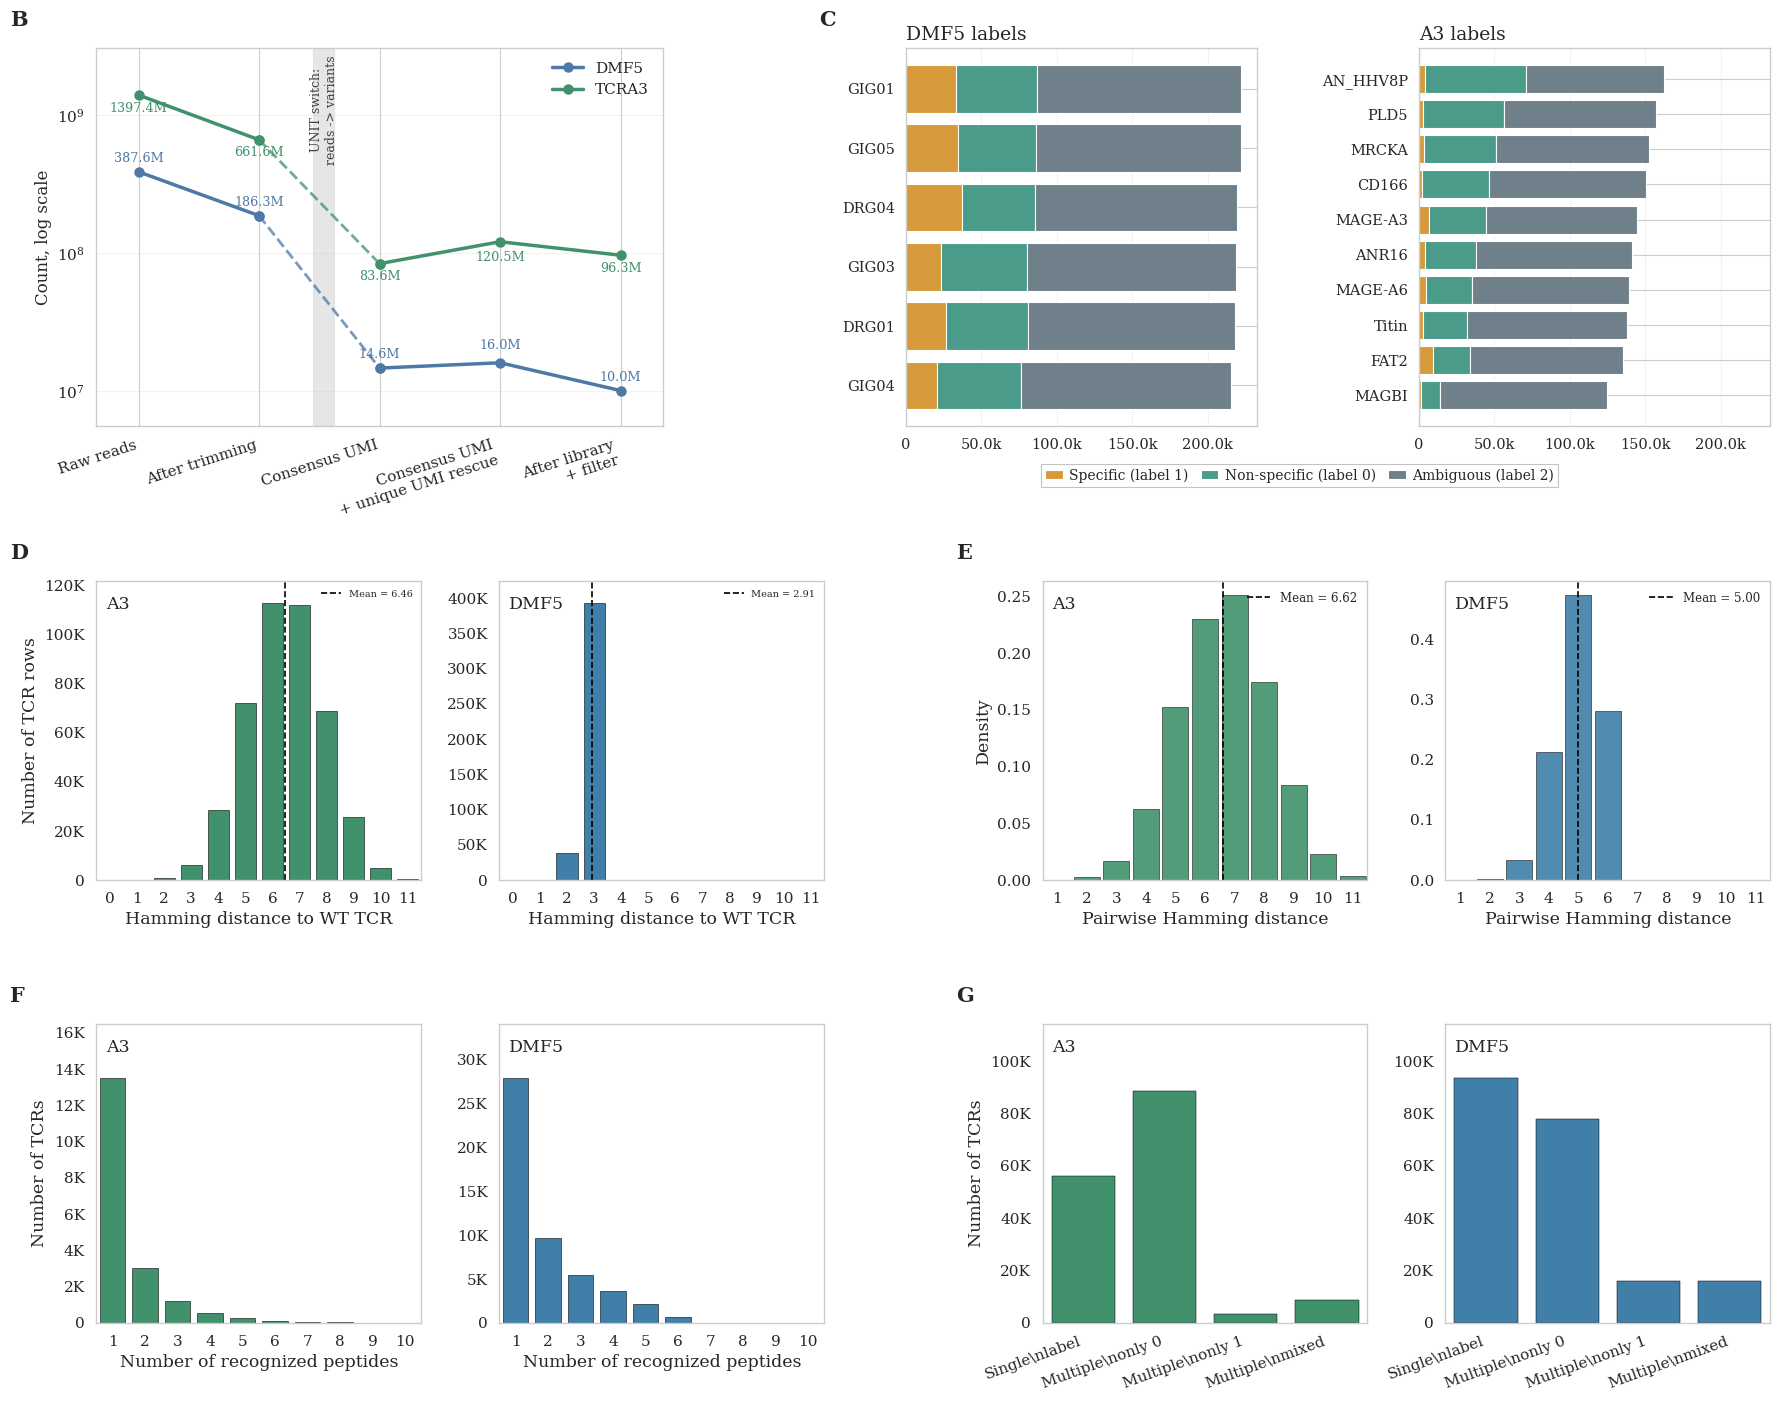

In [30]:
fig_full = make_full_thesis_figure(
    stage_counts,
    consensus_bridge,
    dropout,
    variants,
    wt_distance_counts,
    pairwise_distances,
    crossreact_depth,
    single_binder_context,
    label_multiplicity_counts,
    dataset_analysis_validation,
)
overview_out = OUTPUT_DIR / 'thesis_ngs_pipeline_overview_from_notebook.png'
fig_full.savefig(overview_out, dpi=300, bbox_inches='tight', facecolor='white')
print('Saved:', overview_out)
plt.show()
